## Implementation of Deep Neural Networks

In [ ]:
pip install ucimlrepo

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
wine_quality = fetch_ucirepo(id=186)

# data (as pandas dataframes)
X = wine_quality.data.features
y = wine_quality.data.targets

Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')


In [ ]:
print(X.columns)
print(y.columns)

Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')
Index(['quality'], dtype='object')


In [ ]:
# creating the dataframe from X and y
df = pd.concat([X, y], axis=1)
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
df.size

77964

In [ ]:
df.shape

(6497, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 609.2 KB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed_acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile_acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric_acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual_sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free_sulfur_dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total_sulfur_dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


In [ ]:
df.isnull().sum()

,0
fixed_acidity,0
volatile_acidity,0
citric_acid,0
residual_sugar,0
chlorides,0
free_sulfur_dioxide,0
total_sulfur_dioxide,0
density,0
pH,0
sulphates,0


In [ ]:
# chceking the duplicates
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)

1179


In [ ]:
df.shape

(5318, 12)

In [ ]:
df['quality'].unique()

array([5, 6, 7, 4, 8, 3, 9])

In [ ]:
df['quality'].value_counts()

,count
quality,
6,2323
5,1751
7,855
4,206
8,148
3,30
9,5


In [ ]:
df.columns

Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['quality'] = le.fit_transform(df['quality'])
print(df['quality'].value_counts())

quality
3    2323
2    1751
4     855
1     206
5     148
0      30
6       5
Name: count, dtype: int64


In [ ]:
df.sample(10)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
2994,6.9,0.190,0.33,1.6,0.039,27.0,98.0,0.98980,3.09,0.46,12.3,4
1227,9.0,0.580,0.25,2.0,0.104,8.0,21.0,0.99769,3.27,0.72,9.6,2
1125,8.8,0.240,0.35,1.7,0.055,13.0,27.0,0.99394,3.14,0.59,11.3,4
4864,4.2,0.215,0.23,5.1,0.041,64.0,157.0,0.99688,3.42,0.44,8.0,0
5882,6.0,0.200,0.26,6.8,0.049,22.0,93.0,0.99280,3.15,0.42,11.0,3
4766,5.6,0.280,0.40,6.1,0.034,36.0,118.0,0.99144,3.21,0.43,12.1,4
3272,6.6,0.270,0.31,5.3,0.137,35.0,163.0,0.99510,3.20,0.38,9.3,2
6380,5.6,0.300,0.10,6.4,0.043,34.0,142.0,0.99382,3.14,0.48,9.8,2
4522,6.9,0.220,0.31,6.3,0.029,41.0,131.0,0.99326,3.08,0.49,10.8,3
1842,6.8,0.240,0.34,2.7,0.047,64.5,218.5,0.99340,3.30,0.58,9.7,3


# TASK

In [ ]:
# importing libraries
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

In [ ]:
# laoding the dataset
data = load_wine()
X, y = data.data, data.target

# train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [ ]:
# normalise dataset
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# converting the data into tensors
X_train = torch.tensor(X_train, dtype = torch.float32)
X_test = torch.tensor(X_test, dtype = torch.float32)

y_train = torch.tensor(y_train, dtype = torch.long)
y_test = torch.tensor(y_test, dtype = torch.long)

Model Architecture
1. Input = 13 features
2. Hidden layers = 2
3. Activation = ReLU

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden1, hidden2, output_dim, dropout_rate=0.0):
        super(MLP, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(hidden1, hidden2),
            nn.ReLU(),

            nn.Linear(hidden2, output_dim)
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
# training function
def train_model(model, optimizer, criterion, X_train, y_train, epochs=100):
    train_loss = []

    for epoch in range(epochs):
        model.train()

        optimizer.zero_grad()
        outputs = model(X_train)

        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()

        train_loss.append(loss.item())

    return train_loss

In [ ]:
def evaluate(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        outputs = model(X_test)
        _, predicted = torch.max(outputs, 1)
        accuracy = (predicted == y_test).sum().item() / len(y_test)

    return accuracy

In [ ]:
# without dropout
model = MLP(input_dim=13, hidden1=64, hidden2=32, output_dim=3)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

losses = train_model(model, optimizer, criterion, X_train, y_train)

acc = evaluate(model, X_test, y_test)
print("Accuracy:", acc)

Accuracy: 1.0


In [ ]:
# with dropout
model_dropout = MLP(13, 64, 32, 3, dropout_rate=0.5)

optimizer = optim.Adam(model_dropout.parameters(), lr=0.001, weight_decay=1e-4)

losses_dropout = train_model(model_dropout, optimizer, criterion, X_train, y_train)

acc_dropout = evaluate(model_dropout, X_test, y_test)
print("Accuracy with dropout:", acc_dropout)

Accuracy with dropout: 1.0


In [ ]:
# Hyperparameter tuning
learning_rates = [0.1, 0.01, 0.001]

for lr in learning_rates:
    model = MLP(13, 64, 32, 3)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_model(model, optimizer, criterion, X_train, y_train)

    acc = evaluate(model, X_test, y_test)
    print(f"LR={lr}, Accuracy={acc}")

LR=0.1, Accuracy=1.0
LR=0.01, Accuracy=1.0
LR=0.001, Accuracy=1.0


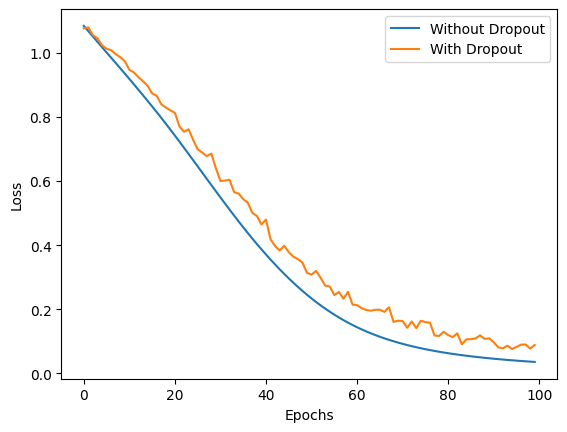

In [ ]:
# plotting loss curve
plt.plot(losses, label='Without Dropout')
plt.plot(losses_dropout, label='With Dropout')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
def train_with_early_stopping(model, optimizer, criterion,
                              X_train, y_train,
                              X_val, y_val,
                              epochs=100,
                              patience=10):

    train_losses = []
    val_losses = []

    best_val_loss = float('inf')
    counter = 0

    for epoch in range(epochs):
        # ---- Training ----
        model.train()
        optimizer.zero_grad()

        outputs = model(X_train)
        loss = criterion(outputs, y_train)

        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        # ---- Validation ----
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val)
            val_loss = criterion(val_outputs, y_val)

        val_losses.append(val_loss.item())

        print(f"Epoch {epoch+1}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}")

        # ---- Early Stopping Logic ----
        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            counter = 0  # reset counter
        else:
            counter += 1

        if counter >= patience:
            print("🚀 Early Stopping Triggered!")
            break

    return train_losses, val_losses

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# Convert to tensors
X_val = torch.FloatTensor(X_val)
y_val = torch.LongTensor(y_val)

1. Early stopping monitors validation loss
2. Stops training when model starts overfitting
3. patience = 5 → waits 10 epochs before stopping
4. Helps improve generalization

In [ ]:
# training model with early stopping
model = MLP(13, 64, 32, 3)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses, val_losses = train_with_early_stopping(
    model, optimizer, criterion,
    X_train, y_train,
    X_val, y_val,
    epochs=100,
    patience=4
)

Epoch 1, Train Loss: 1.1106, Val Loss: 1.1073
Epoch 2, Train Loss: 1.0960, Val Loss: 1.0949
Epoch 3, Train Loss: 1.0817, Val Loss: 1.0826
Epoch 4, Train Loss: 1.0673, Val Loss: 1.0701
Epoch 5, Train Loss: 1.0530, Val Loss: 1.0576
Epoch 6, Train Loss: 1.0388, Val Loss: 1.0449
Epoch 7, Train Loss: 1.0246, Val Loss: 1.0320
Epoch 8, Train Loss: 1.0106, Val Loss: 1.0192
Epoch 9, Train Loss: 0.9965, Val Loss: 1.0062
Epoch 10, Train Loss: 0.9826, Val Loss: 0.9929
Epoch 11, Train Loss: 0.9687, Val Loss: 0.9793
Epoch 12, Train Loss: 0.9546, Val Loss: 0.9657
Epoch 13, Train Loss: 0.9404, Val Loss: 0.9519
Epoch 14, Train Loss: 0.9259, Val Loss: 0.9380
Epoch 15, Train Loss: 0.9112, Val Loss: 0.9237
Epoch 16, Train Loss: 0.8962, Val Loss: 0.9091
Epoch 17, Train Loss: 0.8811, Val Loss: 0.8943
Epoch 18, Train Loss: 0.8658, Val Loss: 0.8793
Epoch 19, Train Loss: 0.8503, Val Loss: 0.8641
Epoch 20, Train Loss: 0.8345, Val Loss: 0.8485
Epoch 21, Train Loss: 0.8184, Val Loss: 0.8328
Epoch 22, Train Loss: 

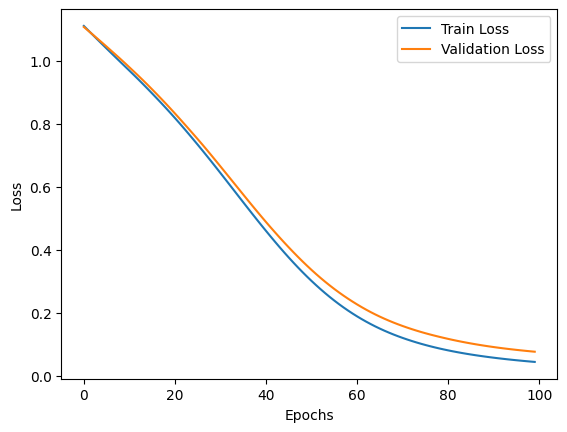

In [ ]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

## Using TensorFlow + Keras

In [ ]:
# import libraries
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.utils import plot_model

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

In [ ]:
# loading and preprocessing of dataset
data = load_wine()
X = data.data
y = data.target

# train-Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# train-Validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42)

# normalization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [ ]:
# building MLP model
def build_model(dropout_rate=0.0, learning_rate=0.001):
    model = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(13,)),
        layers.Dropout(dropout_rate),

        layers.Dense(32, activation='relu'),

        layers.Dense(3, activation='softmax')])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'])

    return model

In [ ]:
# early stopping
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True)

In [ ]:
# training without dropout
model = build_model()

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    callbacks=[early_stopping],
    verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 124ms/step - accuracy: 0.3717 - loss: 1.0375 - val_accuracy: 0.4138 - val_loss: 1.0438
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5575 - loss: 0.9143 - val_accuracy: 0.4828 - val_loss: 0.9362
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7522 - loss: 0.8143 - val_accuracy: 0.6207 - val_loss: 0.8466
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8584 - loss: 0.7270 - val_accuracy: 0.8276 - val_loss: 0.7640
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9115 - loss: 0.6446 - val_accuracy: 0.8621 - val_loss: 0.6876
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9381 - loss: 0.5699 - val_accuracy: 0.8966 - val_loss: 0.6114
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9381 - loss: 0.4954 - val_accuracy: 0.8966 - val_loss: 0.5404
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9469 - loss: 0.4296 - val_accuracy: 0.8966 - val_loss

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,227 (36.05 KB)

 Trainable params: 3,075 (12.01 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,152 (24.04 KB)

In [ ]:
# evaluating the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 1.0000 - loss: 0.0039
Test Accuracy: 1.0


In [ ]:
# trainging model with Dropout
model_dropout = build_model(dropout_rate=0.5)

history_dropout = model_dropout.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    callbacks=[early_stopping],
    verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 370ms/step - accuracy: 0.3009 - loss: 1.2358 - val_accuracy: 0.4828 - val_loss: 1.0855
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - accuracy: 0.4159 - loss: 1.0855 - val_accuracy: 0.5172 - val_loss: 0.9778
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.4602 - loss: 0.9976 - val_accuracy: 0.6552 - val_loss: 0.8846
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step - accuracy: 0.4867 - loss: 0.9741 - val_accuracy: 0.7586 - val_loss: 0.7998
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.6991 - loss: 0.7767 - val_accuracy: 0.9310 - val_loss: 0.7209
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.7611 - loss: 0.7635 - val_accuracy: 0.9310 - val_loss: 0.6492
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.7876 - loss: 0.6766 - val_accuracy: 1.0000 - val_loss: 0.5834
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.8584 - loss: 0.5983 - val_accuracy: 1.0000 - val_

In [ ]:
# evaluating module after using droput
test_loss_d, test_acc_d = model_dropout.evaluate(X_test, y_test)
print("Test Accuracy with Dropout:", test_acc_d)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4444 - loss: 1.0749
Test Accuracy with Dropout: 0.4444444477558136


In [ ]:
# Hyperparameter tuning
learning_rates = [0.1, 0.01, 0.001]

for lr in learning_rates:
    print(f"\nTraining with learning rate = {lr}")

    model = build_model(learning_rate=lr)

    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        callbacks=[early_stopping],
        verbose=1
    )

    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"Accuracy: {acc}")


Training with learning rate = 0.1
Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - accuracy: 0.7345 - loss: 0.6487 - val_accuracy: 0.9310 - val_loss: 0.3818
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9292 - loss: 0.9220 - val_accuracy: 1.0000 - val_loss: 0.0080
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9292 - loss: 0.5681 - val_accuracy: 0.8966 - val_loss: 0.6431
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9735 - loss: 0.2667 - val_accuracy: 1.0000 - val_loss: 0.0064
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 0.0088 - val_accuracy: 0.9655 - val_loss: 0.1038
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9646 - loss: 0.0646 - val_accuracy: 0.9310 - val_loss: 0.1452
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9912 - loss: 0.0248 - val_accuracy: 0.9655 - val_loss: 0.2139
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9912 - loss: 0.0121 - val_

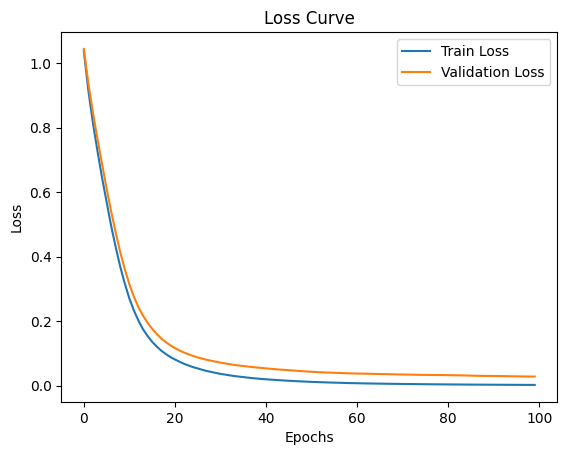

In [ ]:
# plotting the loss curve
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()